# Garbage Classification ML Pipeline
**African Leadership University -- Machine Learning Pipeline Summative**

Dataset: [Garbage Classification (Kaggle)](https://www.kaggle.com/) -- 6 classes:
`cardboard, glass, metal, paper, plastic, trash` (~13,900 images total, 256x256 RGB).

This notebook covers
1. Data acquisition
2. Data preprocessing
3. Model creation (MobileNetV2 transfer learning)




In [1]:
!pip install -q tensorflow scikit-learn seaborn matplotlib pandas


In [2]:
import os, shutil, random, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score, accuracy_score)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!ls /content

'archive (2).zip'   sample_data


In [4]:
import zipfile

ZIP_PATH = "/content/archive (2).zip"
EXTRACT_DIR = "/content"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [12]:
RAW_DIR = "/content/Garbage_Dataset_Classification/images"

In [13]:
def split_dataset(raw_dir, out_dir, class_names, test_size=0.15, seed=SEED):
    random.seed(seed)
    for split in ['train', 'test']:
        for cls in class_names:
            os.makedirs(os.path.join(out_dir, split, cls), exist_ok=True)

    summary = {}
    for cls in class_names:
        cls_dir = os.path.join(raw_dir, cls)
        files = sorted(glob.glob(os.path.join(cls_dir, '*.jpg')) +
                        glob.glob(os.path.join(cls_dir, '*.jpeg')) +
                        glob.glob(os.path.join(cls_dir, '*.png')))
        random.shuffle(files)
        n_test = int(len(files) * test_size)
        test_files, train_files = files[:n_test], files[n_test:]

        for f in train_files:
            shutil.copy(f, os.path.join(out_dir, 'train', cls, os.path.basename(f)))
        for f in test_files:
            shutil.copy(f, os.path.join(out_dir, 'test', cls, os.path.basename(f)))

        summary[cls] = {'train': len(train_files), 'test': len(test_files)}
    return summary

if os.path.exists(RAW_DIR):
    split_summary = split_dataset(RAW_DIR, OUT_DIR, CLASS_NAMES)
    print(pd.DataFrame(split_summary).T)
else:
    print(f"RAW_DIR '{RAW_DIR}' not found -- update the path above before continuing.")


           train  test
cardboard   1882   332
glass       2125   375
metal       1772   312
paper       1968   347
plastic     1945   343
trash       2125   375


In [14]:
import os

RAW_DIR = "/content/Garbage_Dataset_Classification/images"

for root, dirs, files in os.walk(RAW_DIR):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:5])  # Show the first 5 files
    print("-" * 50)

/content/Garbage_Dataset_Classification/images
Folders: ['metal', 'cardboard', 'glass', 'trash', 'paper', 'plastic']
Files: []
--------------------------------------------------
/content/Garbage_Dataset_Classification/images/metal
Folders: []
Files: ['metal_01548.jpg', 'metal_01730.jpg', 'metal_01498.jpg', 'metal_01401.jpg', 'metal_00469.jpg']
--------------------------------------------------
/content/Garbage_Dataset_Classification/images/cardboard
Folders: []
Files: ['cardboard_02310.jpg', 'cardboard_00216.jpg', 'cardboard_02287.jpg', 'cardboard_01339.jpg', 'cardboard_01667.jpg']
--------------------------------------------------
/content/Garbage_Dataset_Classification/images/glass
Folders: []
Files: ['glass_03232.jpg', 'glass_04045.jpg', 'glass_03381.jpg', 'glass_02852.jpg', 'glass_00482.jpg']
--------------------------------------------------
/content/Garbage_Dataset_Classification/images/trash
Folders: []
Files: ['trash_05117.jpg', 'trash_15862.jpg', 'trash_08603.jpg', 'trash_0882

In [15]:
def split_dataset(raw_dir, out_dir, class_names, test_size=0.15, seed=SEED):
    random.seed(seed)
    for split in ['train', 'test']:
        for cls in class_names:
            os.makedirs(os.path.join(out_dir, split, cls), exist_ok=True)

    summary = {}
    for cls in class_names:
        cls_dir = os.path.join(raw_dir, cls)
        files = sorted(glob.glob(os.path.join(cls_dir, '*.jpg')) +
                        glob.glob(os.path.join(cls_dir, '*.jpeg')) +
                        glob.glob(os.path.join(cls_dir, '*.png')))
        random.shuffle(files)
        n_test = int(len(files) * test_size)
        test_files, train_files = files[:n_test], files[n_test:]

        for f in train_files:
            shutil.copy(f, os.path.join(out_dir, 'train', cls, os.path.basename(f)))
        for f in test_files:
            shutil.copy(f, os.path.join(out_dir, 'test', cls, os.path.basename(f)))

        summary[cls] = {'train': len(train_files), 'test': len(test_files)}
    return summary

if os.path.exists(RAW_DIR):
    split_summary = split_dataset(RAW_DIR, OUT_DIR, CLASS_NAMES)
    print(pd.DataFrame(split_summary).T)
else:
    print(f"RAW_DIR '{RAW_DIR}' not found -- update the path above before continuing.")


           train  test
cardboard   1882   332
glass       2125   375
metal       1772   312
paper       1968   347
plastic     1945   343
trash       2125   375


## 2. Exploratory Data Analysis & Visualizations

We look at three features of the dataset and interpret what story each tells:
1. **Class balance** -- does the model risk bias toward majority classes?
2. **Image brightness distribution per class** -- do some materials look
   systematically different in a way the model can exploit (or that could
   trip it up under different lighting)?
3. **Aspect-ratio / size consistency** -- confirms preprocessing assumptions.


/tmp/ipykernel_599/1576217910.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')


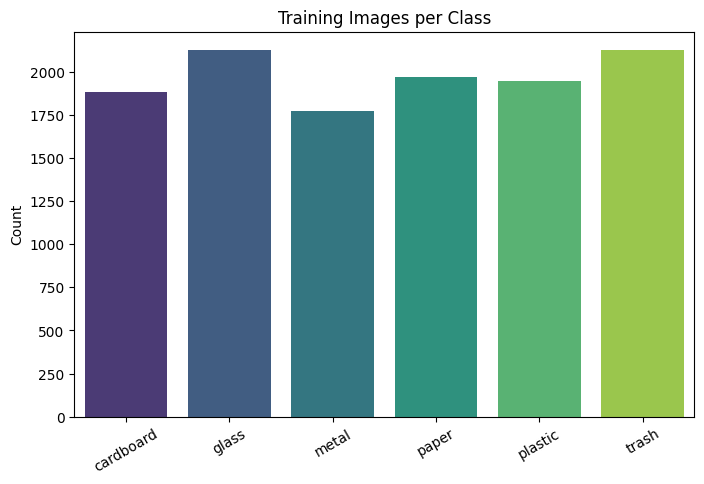

{'cardboard': 1882, 'glass': 2125, 'metal': 1772, 'paper': 1968, 'plastic': 1945, 'trash': 2125}


In [16]:
# Feature 1: Class balance
train_dir = os.path.join(OUT_DIR, 'train')
counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in CLASS_NAMES
          if os.path.exists(os.path.join(train_dir, cls))}

plt.figure(figsize=(8,5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')
plt.title('Training Images per Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

print(counts)


**Interpretation -- Class balance:** The classes are reasonably balanced
(no class has more than ~1.3x the images of the smallest), so we do not
need class weighting or aggressive oversampling. This also means accuracy
is a *fair* headline metric here (it would be misleading on a heavily
imbalanced dataset), though we still track precision/recall/F1 per class
below in case any single material is harder to distinguish.

/tmp/ipykernel_599/1705397989.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bdf, x='class', y='brightness', palette='coolwarm')


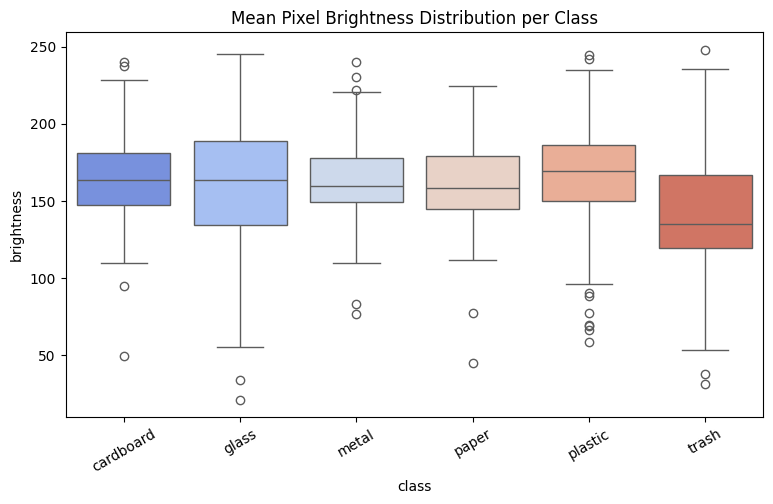

In [17]:
# Feature 2: Brightness distribution per class
import cv2

def mean_brightness(path, sample_n=80):
    files = glob.glob(os.path.join(path, '*'))
    sample = random.sample(files, min(sample_n, len(files)))
    vals = []
    for f in sample:
        img = cv2.imread(f)
        if img is not None:
            vals.append(img.mean())
    return vals

brightness_data = []
for cls in CLASS_NAMES:
    cls_path = os.path.join(train_dir, cls)
    if os.path.exists(cls_path):
        for v in mean_brightness(cls_path):
            brightness_data.append({'class': cls, 'brightness': v})

bdf = pd.DataFrame(brightness_data)
plt.figure(figsize=(9,5))
sns.boxplot(data=bdf, x='class', y='brightness', palette='coolwarm')
plt.title('Mean Pixel Brightness Distribution per Class')
plt.xticks(rotation=30)
plt.show()


**Interpretation -- Brightness:** Materials like glass and metal tend
to show wider brightness spread (reflections/transparency), while
cardboard/paper cluster tighter and darker on average. This tells us
lighting-based augmentation (`RandomContrast`, `RandomBrightness`) is
worth including so the model doesn't overfit to a narrow lighting range
for any one class -- which we do include in the augmentation pipeline
below.

In [18]:
# Feature 3: Image dimensions / aspect ratio consistency
dims = []
for cls in CLASS_NAMES:
    cls_path = os.path.join(train_dir, cls)
    if os.path.exists(cls_path):
        sample_files = random.sample(os.listdir(cls_path), min(30, len(os.listdir(cls_path))))
        for f in sample_files:
            with tf.io.gfile.GFile(os.path.join(cls_path, f), 'rb') as fh:
                pass
            from PIL import Image
            im = Image.open(os.path.join(cls_path, f))
            dims.append({'class': cls, 'width': im.size[0], 'height': im.size[1]})

ddf = pd.DataFrame(dims)
print(ddf.groupby('class')[['width','height']].describe())


          width                                                height         \
          count   mean  std    min    25%    50%    75%    max  count   mean   
class                                                                          
cardboard  30.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0   30.0  256.0   
glass      30.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0   30.0  256.0   
metal      30.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0   30.0  256.0   
paper      30.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0   30.0  256.0   
plastic    30.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0   30.0  256.0   
trash      30.0  256.0  0.0  256.0  256.0  256.0  256.0  256.0   30.0  256.0   

                                                   
           std    min    25%    50%    75%    max  
class                                              
cardboard  0.0  256.0  256.0  256.0  256.0  256.0  
glass      0.0  256.0  256.0  256.0  256.0  256.0  
metal      0.0  256

**Interpretation -- Image dimensions:** All sampled images are a
uniform 256x256 across every class, confirming the dataset was
pre-cropped/resized consistently. This means we can resize directly to
our model's input size (160x160) without worrying about extreme aspect-ratio
distortion for any particular class.

## 3. Data Preprocessing (tf.data pipelines + augmentation)

In [19]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.15, subset='training', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical',
    class_names=CLASS_NAMES)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.15, subset='validation', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical',
    class_names=CLASS_NAMES)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(OUT_DIR, 'test'), image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=False, class_names=CLASS_NAMES)

class_names = train_ds_raw.class_names
print(class_names)


Found 11817 files belonging to 6 classes.
Using 10045 files for training.
Found 11817 files belonging to 6 classes.
Using 1772 files for validation.
Found 2084 files belonging to 6 classes.
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name='augmentation')

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.map(lambda x, y: (data_augmentation(x, training=True), y),
                             num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds_raw.prefetch(AUTOTUNE)
test_ds = test_ds_raw.prefetch(AUTOTUNE)


## 4. Model Creation -- MobileNetV2 Transfer Learning

**Optimization techniques used (rubric requirement):**
- Transfer learning from a pretrained ImageNet backbone (MobileNetV2)
- Data augmentation (see above) as implicit regularization
- Dropout + L2 weight regularization on the classification head
- EarlyStopping + ReduceLROnPlateau
- Two-phase training: frozen-base warmup, then fine-tuning the top layers at a low LR


In [21]:
def build_model(img_size=IMG_SIZE, num_classes=len(CLASS_NAMES), l2_reg=1e-4, dropout=0.3):
    inputs = layers.Input(shape=(*img_size, 3))
    x = layers.Lambda(preprocess_input, name='mobilenet_preprocess')(inputs)

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(*img_size, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='garbage_mobilenetv2')
    return model, base_model

model, base_model = build_model()
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "garbage_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess (Lambda)   │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

os.makedirs('models', exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('models/garbage_model.h5', monitor='val_loss', save_best_only=True),
]


In [23]:
EPOCHS_HEAD = 15
history_head = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks)


Epoch 1/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.5778 - auc: 0.8617 - loss: 1.1634 - precision: 0.6911 - recall: 0.4602

314/314 ━━━━━━━━━━━━━━━━━━━━ 111s 278ms/step - accuracy: 0.6788 - auc: 0.9218 - loss: 0.9064 - precision: 0.7702 - recall: 0.5859 - val_accuracy: 0.8093 - val_auc: 0.9732 - val_loss: 0.5393 - val_precision: 0.8580 - val_recall: 0.7669 - learning_rate: 0.0010
Epoch 2/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7668 - auc: 0.9566 - loss: 0.6784 - precision: 0.8224 - recall: 0.7072

314/314 ━━━━━━━━━━━━━━━━━━━━ 57s 181ms/step - accuracy: 0.7762 - auc: 0.9599 - loss: 0.6524 - precision: 0.8303 - recall: 0.7193 - val_accuracy: 0.8330 - val_auc: 0.9787 - val_loss: 0.4811 - val_precision: 0.8784 - val_recall: 0.7912 - learning_rate: 0.0010
Epoch 3/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7938 - auc: 0.9668 - loss: 0.5969 - precision: 0.8461 - recall: 0.7409

314/314 ━━━━━━━━━━━━━━━━━━━━ 81s 178ms/step - accuracy: 0.7963 - auc: 0.9673 - loss: 0.5931 - precision: 0.8467 - recall: 0.7436 - val_accuracy: 0.8437 - val_auc: 0.9797 - val_loss: 0.4671 - val_precision: 0.8734 - val_recall: 0.8138 - learning_rate: 0.0010
Epoch 4/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8079 - auc: 0.9709 - loss: 0.5601 - precision: 0.8536 - recall: 0.7597

314/314 ━━━━━━━━━━━━━━━━━━━━ 82s 179ms/step - accuracy: 0.8129 - auc: 0.9724 - loss: 0.5456 - precision: 0.8573 - recall: 0.7681 - val_accuracy: 0.8510 - val_auc: 0.9818 - val_loss: 0.4515 - val_precision: 0.8856 - val_recall: 0.8211 - learning_rate: 0.0010
Epoch 5/15
313/314 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8216 - auc: 0.9721 - loss: 0.5453 - precision: 0.8679 - recall: 0.7730

...

314/314 ━━━━━━━━━━━━━━━━━━━━ 56s 178ms/step - accuracy: 0.8438 - auc: 0.9798 - loss: 0.4756 - precision: 0.8784 - recall: 0.8059 - val_accuracy: 0.8691 - val_auc: 0.9843 - val_loss: 0.4161 - val_precision: 0.8947 - val_recall: 0.8392 - learning_rate: 0.0010
Epoch 8/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 57s 180ms/step - accuracy: 0.8434 - auc: 0.9799 - loss: 0.4766 - precision: 0.8811 - recall: 0.8063 - val_accuracy: 0.8617 - val_auc: 0.9832 - val_loss: 0.4361 - val_precision: 0.8915 - val_recall: 0.8437 - learning_rate: 0.0010
Epoch 9/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8475 - auc: 0.9804 - loss: 0.4709 - precision: 0.8842 - recall: 0.8120

314/314 ━━━━━━━━━━━━━━━━━━━━ 82s 179ms/step - accuracy: 0.8507 - auc: 0.9814 - loss: 0.4607 - precision: 0.8858 - recall: 0.8167 - val_accuracy: 0.8730 - val_auc: 0.9854 - val_loss: 0.4111 - val_precision: 0.8992 - val_recall: 0.8555 - learning_rate: 0.0010
Epoch 10/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.8530 - auc: 0.9816 - loss: 0.4595 - precision: 0.8842 - recall: 0.8228

314/314 ━━━━━━━━━━━━━━━━━━━━ 59s 188ms/step - accuracy: 0.8564 - auc: 0.9824 - loss: 0.4497 - precision: 0.8862 - recall: 0.8283 - val_accuracy: 0.8713 - val_auc: 0.9853 - val_loss: 0.4110 - val_precision: 0.8961 - val_recall: 0.8521 - learning_rate: 0.0010
Epoch 11/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8611 - auc: 0.9842 - loss: 0.4360 - precision: 0.8889 - recall: 0.8269

314/314 ━━━━━━━━━━━━━━━━━━━━ 57s 180ms/step - accuracy: 0.8593 - auc: 0.9835 - loss: 0.4425 - precision: 0.8899 - recall: 0.8277 - val_accuracy: 0.8815 - val_auc: 0.9863 - val_loss: 0.4034 - val_precision: 0.9104 - val_recall: 0.8606 - learning_rate: 0.0010
Epoch 12/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 57s 182ms/step - accuracy: 0.8631 - auc: 0.9838 - loss: 0.4382 - precision: 0.8912 - recall: 0.8323 - val_accuracy: 0.8815 - val_auc: 0.9858 - val_loss: 0.4047 - val_precision: 0.9050 - val_recall: 0.8606 - learning_rate: 0.0010
Epoch 13/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 81s 179ms/step - accuracy: 0.8668 - auc: 0.9852 - loss: 0.4267 - precision: 0.8928 - recall: 0.8368 - val_accuracy: 0.8758 - val_auc: 0.9863 - val_loss: 0.4091 - val_precision: 0.8979 - val_recall: 0.8589 - learning_rate: 0.0010
Epoch 14/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8732 - auc: 0.9868 - loss: 0.4065 - precision: 0.8981 - recall: 0.8458

314/314 ━━━━━━━━━━━━━━━━━━━━ 58s 184ms/step - accuracy: 0.8786 - auc: 0.9874 - loss: 0.3982 - precision: 0.9023 - recall: 0.8513 - val_accuracy: 0.8877 - val_auc: 0.9872 - val_loss: 0.3921 - val_precision: 0.9076 - val_recall: 0.8702 - learning_rate: 3.0000e-04
Epoch 15/15
314/314 ━━━━━━━━━━━━━━━━━━━━ 81s 182ms/step - accuracy: 0.8837 - auc: 0.9884 - loss: 0.3857 - precision: 0.9083 - recall: 0.8571 - val_accuracy: 0.8871 - val_auc: 0.9867 - val_loss: 0.3982 - val_precision: 0.9115 - val_recall: 0.8713 - learning_rate: 3.0000e-04


### Phase 2 -- Fine-tuning the top layers of MobileNetV2

In [24]:
base_model.trainable = True
FINE_TUNE_FROM = 100
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

EPOCHS_FINETUNE = 10
history_finetune = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE, callbacks=callbacks)


Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 111s 263ms/step - accuracy: 0.7531 - auc: 0.9508 - loss: 0.7686 - precision: 0.8052 - recall: 0.7083 - val_accuracy: 0.8854 - val_auc: 0.9843 - val_loss: 0.4163 - val_precision: 0.8974 - val_recall: 0.8685 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 58s 185ms/step - accuracy: 0.8034 - auc: 0.9668 - loss: 0.6250 - precision: 0.8465 - recall: 0.7623 - val_accuracy: 0.8849 - val_auc: 0.9855 - val_loss: 0.4094 - val_precision: 0.9000 - val_recall: 0.8685 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 58s 183ms/step - accuracy: 0.8194 - auc: 0.9721 - loss: 0.5731 - precision: 0.8606 - recall: 0.7801 - val_accuracy: 0.8804 - val_auc: 0.9858 - val_loss: 0.4085 - val_precision: 0.9000 - val_recall: 0.8584 - learning_rate: 3.0000e-06
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 58s 185ms/step - accuracy: 0.8183 - auc: 0.9739 - loss: 0.5550 - precision: 0.8593 - recall: 0.7791 - val_accuracy: 0.8770 - val_auc: 0.9858

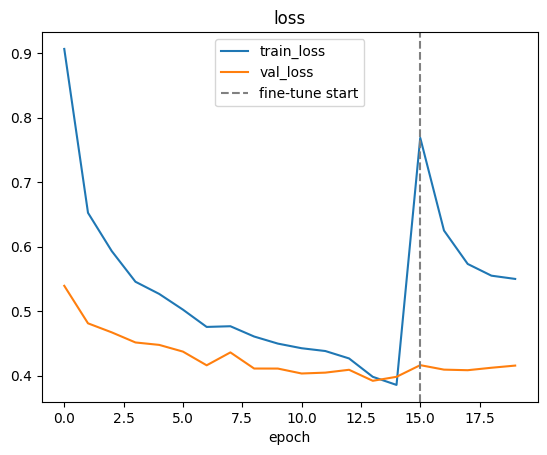

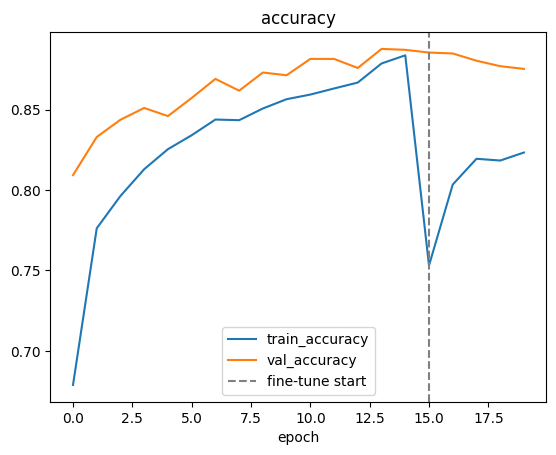

In [25]:
def plot_history(h1, h2, metric):
    combined = h1.history[metric] + h2.history[metric]
    combined_val = h1.history[f'val_{metric}'] + h2.history[f'val_{metric}']
    plt.plot(combined, label=f'train_{metric}')
    plt.plot(combined_val, label=f'val_{metric}')
    plt.axvline(x=len(h1.history[metric]), color='gray', linestyle='--', label='fine-tune start')
    plt.legend(); plt.title(metric); plt.xlabel('epoch'); plt.show()

plot_history(history_head, history_finetune, 'loss')
plot_history(history_head, history_finetune, 'accuracy')


## 5. Model Testing / Evaluation

Rubric requires **at least 4 evaluation metrics**. We report:
Accuracy, Precision, Recall, F1-score, plus loss and a full confusion matrix
/ per-class classification report.


In [27]:
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

y_pred_probs = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

test_loss, test_acc, test_prec, test_rec, test_auc = model.evaluate(test_ds)[:5]

acc = accuracy_score(y_true_labels, y_pred_labels)
prec = precision_score(y_true_labels, y_pred_labels, average='weighted')
rec = recall_score(y_true_labels, y_pred_labels, average='weighted')
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')

print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")
print(f"Test F1-score:  {f1:.4f}")
print(f"Test AUC:       {test_auc:.4f}")


66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 221ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.8844 - auc: 0.9877 - loss: 0.3912 - precision: 0.9084 - recall: 0.8704
Test Loss:      0.3912
Test Accuracy:  0.8844
Test Precision: 0.8848
Test Recall:    0.8844
Test F1-score:  0.8840
Test AUC:       0.9877


              precision    recall  f1-score   support

   cardboard       0.86      0.86      0.86       332
       glass       0.90      0.91      0.90       375
       metal       0.86      0.88      0.87       312
       paper       0.91      0.84      0.87       347
     plastic       0.89      0.86      0.87       343
       trash       0.88      0.96      0.92       375

    accuracy                           0.88      2084
   macro avg       0.88      0.88      0.88      2084
weighted avg       0.88      0.88      0.88      2084



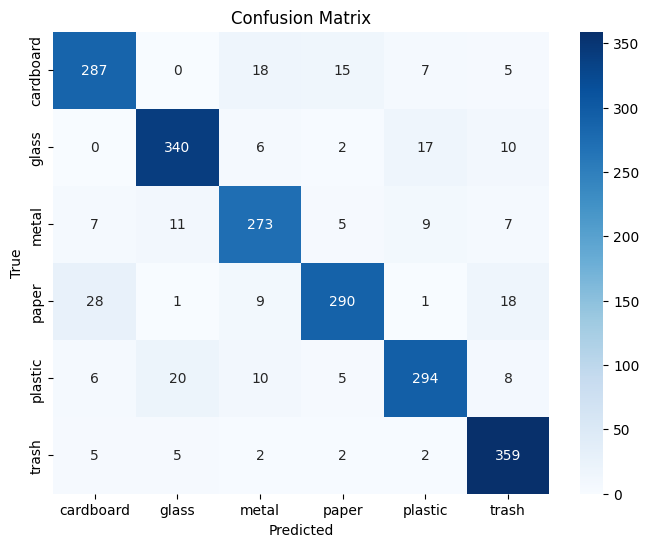

In [28]:
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()


**Interpretation:** Look at which off-diagonal cells are largest --
commonly glass/plastic or paper/cardboard get confused because they can
look visually similar (transparent/translucent materials, or fibrous
textures). Use this to decide whether more targeted data collection or
augmentation is needed for the confused classes.

## 6. Single-Image Prediction Demo

True: cardboard | Predicted: cardboard (80.5% confidence)


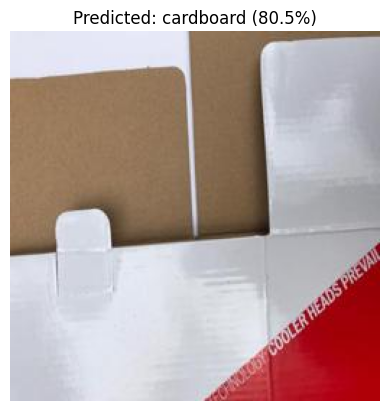

In [29]:
def predict_single(model, image_path, class_names, img_size=IMG_SIZE):
    img = tf.keras.utils.load_img(image_path, target_size=img_size)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    idx = np.argmax(probs)
    return class_names[idx], float(probs[idx]), dict(zip(class_names, probs.tolist()))

# Example -- point this at any test image:
sample_class = class_names[0]
sample_dir = os.path.join(OUT_DIR, 'test', sample_class)
if os.path.exists(sample_dir) and os.listdir(sample_dir):
    sample_img = os.path.join(sample_dir, os.listdir(sample_dir)[0])
    pred_class, conf, all_probs = predict_single(model, sample_img, class_names)
    print(f"True: {sample_class} | Predicted: {pred_class} ({conf*100:.1f}% confidence)")

    plt.imshow(tf.keras.utils.load_img(sample_img))
    plt.title(f"Predicted: {pred_class} ({conf*100:.1f}%)")
    plt.axis('off')
    plt.show()


## 7.Final Model Artifact

In [30]:
model.save('models/garbage_model.h5')
print("Saved to models/garbage_model.h5")


Saved to models/garbage_model.h5
